# PSKGPT : Setup + Config

In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import random
from dataclasses import dataclass

# reproducibility
torch.manual_seed(42)

@dataclass
class Config:
    # model params
    vocab_size = None          # set after tokenizer
    block_size = 128          # max context length
    n_embd = 256             # embedding dimension
    n_head = 8               # attention heads
    n_layer = 6              # transformer blocks
    dropout = 0.1
    bias = True

    # training params
    batch_size = 32
    lr = 3e-4
    max_iters = 3000
    eval_interval = 200

    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()

print("Using Device:", cfg.device)

Using Device: cuda


# PSKGPT : Load Dataset

In [2]:
import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

text = requests.get(url).text

print("Total characters:", len(text))
print("-" * 50)
print(text[:1000])   # preview first 1000 chars

Total characters: 1115394
--------------------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for

# PSKGPT : Tokenizer

In [3]:
# unique characters in dataset
chars = sorted(list(set(text)))

vocab_size = len(chars)
cfg.vocab_size = vocab_size

print("Vocabulary Size:", vocab_size)
print(chars)

# char -> id
stoi = {ch: i for i, ch in enumerate(chars)}

# id -> char
itos = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return ''.join([itos[i] for i in ids])

# quick test
sample = "Hello!"
encoded = encode(sample)
decoded = decode(encoded)

print("Sample Text :", sample)
print("Encoded     :", encoded)
print("Decoded     :", decoded)

Vocabulary Size: 65
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Sample Text : Hello!
Encoded     : [20, 43, 50, 50, 53, 2]
Decoded     : Hello!


# PSKGPT : Dataset + Batch Loader

In [4]:

# convert entire text to token ids
data = torch.tensor(encode(text), dtype=torch.long)

print("Total tokens:", len(data))
print("First 50 tokens:", data[:50])

# train / validation split
split = int(0.9 * len(data))
train_data = data[:split]
val_data   = data[split:]

print("Train tokens:", len(train_data))
print("Val tokens  :", len(val_data))


def get_batch(split_name="train"):
    source = train_data if split_name == "train" else val_data
    
    ix = torch.randint(len(source) - cfg.block_size - 1, (cfg.batch_size,))
    
    x = torch.stack([source[i : i + cfg.block_size] for i in ix])
    y = torch.stack([source[i + 1 : i + cfg.block_size + 1] for i in ix])
    
    x, y = x.to(cfg.device), y.to(cfg.device)
    return x, y


# quick test
xb, yb = get_batch("train")

print("Input shape :", xb.shape)
print("Target shape:", yb.shape)
print("One sample input :", xb[0][:20])
print("One sample target:", yb[0][:20])

Total tokens: 1115394
First 50 tokens: tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56])
Train tokens: 1003854
Val tokens  : 111540
Input shape : torch.Size([32, 128])
Target shape: torch.Size([32, 128])
One sample input : tensor([ 1, 54, 39, 57, 57, 39, 45, 43,  8,  0,  0, 31, 43, 41, 53, 52, 42,  1,
        35, 39], device='cuda:0')
One sample target: tensor([54, 39, 57, 57, 39, 45, 43,  8,  0,  0, 31, 43, 41, 53, 52, 42,  1, 35,
        39, 58], device='cuda:0')


In [5]:
xb, yb = get_batch()
print(decode(xb[0].tolist()))
print("-----")
print(decode(yb[0].tolist()))

ffair. I humbly thank you:
Commend me to my brother: soon at night
I'll send him certain word of my success.

LUCIO:
I take my l
-----
fair. I humbly thank you:
Commend me to my brother: soon at night
I'll send him certain word of my success.

LUCIO:
I take my le


# PSKGPT : Single Head Self Attention


In [6]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()

        self.key   = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.query = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.value = nn.Linear(cfg.n_embd, head_size, bias=False)

        self.dropout = nn.Dropout(cfg.dropout)

        self.register_buffer(
            "tril",
            torch.tril(torch.ones(cfg.block_size, cfg.block_size))
        )

        self.last_attn = None   # 🔥 store attention

    def forward(self, x):
        B, T, C = x.shape

        K = self.key(x)
        Q = self.query(x)

        wei = Q @ K.transpose(-2, -1) * (K.shape[-1] ** -0.5)

        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)

        self.last_attn = wei.detach()   # 🔥 store

        wei = self.dropout(wei)

        V = self.value(x)
        out = wei @ V

        return out

In [7]:
head_size = cfg.n_embd // cfg.n_head
head = Head(head_size).to(cfg.device)

xb, yb = get_batch()
x = torch.randn(cfg.batch_size, cfg.block_size, cfg.n_embd).to(cfg.device)

out = head(x)
print(out.shape)

torch.Size([32, 128, 32])


# PSKGPT : Multi Head Attention

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()

        head_size = cfg.n_embd // cfg.n_head

        self.heads = nn.ModuleList(
            [Head(head_size) for _ in range(cfg.n_head)]
        )

        self.proj = nn.Linear(cfg.n_embd, cfg.n_embd)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x):
        # run all heads in parallel and concatenate
        out = torch.cat([h(x) for h in self.heads], dim=-1)

        # mix all head outputs
        out = self.proj(out)
        out = self.dropout(out)

        return out

In [9]:
mha = MultiHeadAttention().to(cfg.device)

x = torch.randn(cfg.batch_size, cfg.block_size, cfg.n_embd).to(cfg.device)

out = mha(x)
print(out.shape)

torch.Size([32, 128, 256])


# PSKGPT :  Feed Forward Network


In [10]:
class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(cfg.n_embd, 4 * cfg.n_embd),
            nn.ReLU(),
            nn.Linear(4 * cfg.n_embd, cfg.n_embd),
            nn.Dropout(cfg.dropout)
        )

    def forward(self, x):
        return self.net(x)

In [11]:
ffn = FeedForward().to(cfg.device)

x = torch.randn(cfg.batch_size, cfg.block_size, cfg.n_embd).to(cfg.device)

out = ffn(x)
print(out.shape)

torch.Size([32, 128, 256])


# PSKGPT :  Transformer Block

In [12]:
class Block(nn.Module):
    def __init__(self):
        super().__init__()

        self.ln1 = nn.LayerNorm(cfg.n_embd)
        self.attn = MultiHeadAttention()

        self.ln2 = nn.LayerNorm(cfg.n_embd)
        self.ffwd = FeedForward()

    def forward(self, x):
        # Attention + residual
        x = x + self.attn(self.ln1(x))

        # FFN + residual
        x = x + self.ffwd(self.ln2(x))

        return x

In [13]:
block = Block().to(cfg.device)

x = torch.randn(cfg.batch_size, cfg.block_size, cfg.n_embd).to(cfg.device)

out = block(x)
print(out.shape)

torch.Size([32, 128, 256])


# PSKGPT :  Full GPT Model


In [14]:
class PSKGPT(nn.Module):
    def __init__(self):
        super().__init__()

        # token embedding table
        self.token_embedding = nn.Embedding(cfg.vocab_size, cfg.n_embd)

        # positional embedding table
        self.position_embedding = nn.Embedding(cfg.block_size, cfg.n_embd)

        # transformer blocks
        self.blocks = nn.Sequential(
            *[Block() for _ in range(cfg.n_layer)]
        )

        # final norm
        self.ln_f = nn.LayerNorm(cfg.n_embd)

        # language modeling head
        self.lm_head = nn.Linear(cfg.n_embd, cfg.vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # token embeddings
        tok_emb = self.token_embedding(idx)          # (B,T,C)

        # positions: [0,1,2,...,T-1]
        pos = torch.arange(T, device=cfg.device)

        # position embeddings
        pos_emb = self.position_embedding(pos)       # (T,C)

        # combine
        x = tok_emb + pos_emb                        # (B,T,C)

        # transformer stack
        x = self.blocks(x)

        # final norm
        x = self.ln_f(x)

        # logits
        logits = self.lm_head(x)                    # (B,T,vocab)

        loss = None
        if targets is not None:
            B, T, V = logits.shape
            logits_flat = logits.view(B * T, V)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
    
            # keep only last block_size tokens
            idx_cond = idx[:, -cfg.block_size:]
    
            # forward pass
            logits, _ = self(idx_cond)
    
            # take last time-step prediction
            logits = logits[:, -1, :]   # (B, vocab)
    
            # convert to probabilities
            probs = F.softmax(logits, dim=-1)
    
            # sample next token
            next_id = torch.multinomial(probs, num_samples=1)
    
            # append token
            idx = torch.cat((idx, next_id), dim=1)
    
        return idx

In [15]:
model = PSKGPT().to(cfg.device)

xb, yb = get_batch()

logits, loss = model(xb, yb)

print("Logits Shape:", logits.shape)
print("Loss:", loss.item())

Logits Shape: torch.Size([32, 128, 65])
Loss: 4.400876522064209


# PSKGPT :  Init Model

In [16]:
model = PSKGPT().to(cfg.device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.lr
)

print("Model Parameters:",
      sum(p.numel() for p in model.parameters()) / 1e6,
      "Million")

Model Parameters: 4.800577 Million


# PSKGPT :  Eval Loss

In [17]:
@torch.no_grad()
def estimate_loss():
    model.eval()

    out = {}

    for split in ["train", "val"]:
        losses = torch.zeros(20)

        for k in range(20):
            xb, yb = get_batch(split)
            _, loss = model(xb, yb)
            losses[k] = loss.item()

        out[split] = losses.mean()

    model.train()
    return out

# PSKGPT :  Training Loop

In [18]:
for step in range(cfg.max_iters):

    # evaluate periodically
    if step % cfg.eval_interval == 0:
        losses = estimate_loss()
        print(f"step {step}: "
              f"train loss {losses['train']:.4f}, "
              f"val loss {losses['val']:.4f}")

    # get batch
    xb, yb = get_batch("train")

    # forward pass
    logits, loss = model(xb, yb)

    # clear old gradients
    optimizer.zero_grad(set_to_none=True)

    # backward pass
    loss.backward()

    # gradient clipping
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    
    # update weights
    optimizer.step()


step 0: train loss 4.3404, val loss 4.3406
step 200: train loss 2.4030, val loss 2.4261
step 400: train loss 2.1635, val loss 2.1923
step 600: train loss 1.9667, val loss 2.0424
step 800: train loss 1.8413, val loss 1.9671
step 1000: train loss 1.7407, val loss 1.8666
step 1200: train loss 1.6645, val loss 1.7960
step 1400: train loss 1.6089, val loss 1.7630
step 1600: train loss 1.5555, val loss 1.7365
step 1800: train loss 1.5227, val loss 1.7040
step 2000: train loss 1.4909, val loss 1.6767
step 2200: train loss 1.4527, val loss 1.6529
step 2400: train loss 1.4346, val loss 1.6367
step 2600: train loss 1.4217, val loss 1.6335
step 2800: train loss 1.3981, val loss 1.6151


# PSKGPT : Inferencing

In [19]:
context = torch.zeros((1,1), dtype=torch.long, device=cfg.device)

generated = model.generate(context, max_new_tokens=500)

print(decode(generated[0].tolist()))


And!
Prolous from me cattarns ere heaven with better;
If God force and him
The comminger.
In Camil Caminius wholes?
I be my daugnt. Your despite of she,
O die whom I dispricion is cut frie.

QUEEN MARGARET:
And my most liege: I mother must I last her.

CAMILLO:
Now, noul here aloneblets as I ray you; five
What my glad dwell my entrange.
Not thy our healts to slaighteries: for then call's
Was up go bear in this dreamsth'd, we is the
sentill courtes, Slargulands for lords! my grown!
O prhamplisiti


In [20]:
prompt = "ROMEO:"
context = torch.tensor([encode(prompt)], dtype=torch.long).to(cfg.device)

generated = model.generate(context, 300)

print(decode(generated[0].tolist()))

ROMEO:
Errown'd; and nain good soldiet! parmil he will:
A madam i' the threasture, Azarl; bount them,
As a krupt, all my defended that I hear I out
At ANGELO:
Some dishallain this from actimforatious to beking?

MERCUTIO:
I braw.

KING RICHARD IIIII:
A mind, what it though and not be not die,
Of or sudrem


In [21]:
prompt = "ROMEO:\n"
context = torch.tensor([encode(prompt)], dtype=torch.long).to(cfg.device)
generated = model.generate(context, 300)
print(decode(generated[0].tolist()))

ROMEO:
Why, for you? is he?

MERCUTIO:
But of breather knee, knower within the horrow-night.

QUEEN ELIZABETH:
O Serrah, I come ye to her.

ESCALUS:
I was home to thousand in purposit:--

HENRY AL:
Came, me come of Warwick out, how like untle not;
Therefore, now your enemies but so so a
a vartage, lent the


In [22]:
def inspect_next_token(prompt, top_k=10):
    context = torch.tensor([encode(prompt)], dtype=torch.long).to(cfg.device)
    
    logits, _ = model(context)
    logits = logits[:, -1, :]
    
    probs = F.softmax(logits, dim=-1)
    
    top_probs, top_idx = torch.topk(probs, top_k)
    
    print(f"\nPrompt: '{prompt}'\n")
    for i in range(top_k):
        token = decode([top_idx[0, i].item()])
        prob = top_probs[0, i].item()
        print(f"{repr(token)} : {prob:.4f}")

In [23]:
inspect_next_token("ROMEO:")


Prompt: 'ROMEO:'

'\n' : 0.9939
' ' : 0.0050
'-' : 0.0004
"'" : 0.0003
'3' : 0.0001
'I' : 0.0000
'c' : 0.0000
'O' : 0.0000
'Y' : 0.0000
':' : 0.0000


In [24]:
def visualize_attention(prompt):
    model.eval()

    context = torch.tensor([encode(prompt)], dtype=torch.long).to(cfg.device)

    # forward pass
    _ = model(context)

    # take first block, first head
    head = model.blocks[0].attn.heads[0]

    attn = head.last_attn[0].cpu()  # (T,T)

    tokens = list(prompt)

    print("\nTokens:", tokens)
    print("\nAttention Matrix:\n")

    for i in range(len(tokens)):
        row = attn[i][:len(tokens)]
        print(f"{tokens[i]} -> ", ["{:.2f}".format(x) for x in row])

In [25]:
visualize_attention("ROMEO:")


Tokens: ['R', 'O', 'M', 'E', 'O', ':']

Attention Matrix:

R ->  ['1.00', '0.00', '0.00', '0.00', '0.00', '0.00']
O ->  ['0.92', '0.08', '0.00', '0.00', '0.00', '0.00']
M ->  ['0.02', '0.89', '0.09', '0.00', '0.00', '0.00']
E ->  ['0.07', '0.02', '0.87', '0.04', '0.00', '0.00']
O ->  ['0.04', '0.22', '0.02', '0.58', '0.14', '0.00']
: ->  ['0.26', '0.04', '0.03', '0.08', '0.56', '0.03']


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_attention(prompt):
    model.eval()

    context = torch.tensor([encode(prompt)], dtype=torch.long).to(cfg.device)
    _ = model(context)

    head = model.blocks[0].attn.heads[0]
    attn = head.last_attn[0].cpu().numpy()

    tokens = list(prompt)

    sns.heatmap(attn[:len(tokens), :len(tokens)],
                xticklabels=tokens,
                yticklabels=tokens,
                cmap="viridis")

    plt.title("Attention Heatmap")
    plt.show()

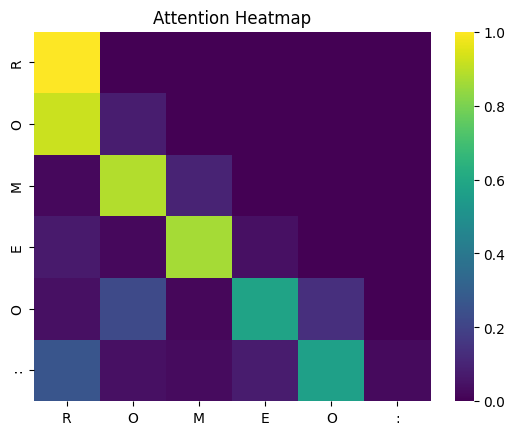

In [27]:
plot_attention("ROMEO:")

In [28]:
def plot_multihead_attention(prompt, block_idx=0):
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    model.eval()

    context = torch.tensor([encode(prompt)], dtype=torch.long).to(cfg.device)
    _ = model(context)

    tokens = list(prompt)
    T = len(tokens)

    heads = model.blocks[block_idx].attn.heads
    num_heads = len(heads)

    fig, axes = plt.subplots(1, num_heads, figsize=(4*num_heads, 4))

    for i, head in enumerate(heads):
        attn = head.last_attn[0].cpu().numpy()

        ax = axes[i] if num_heads > 1 else axes

        sns.heatmap(
            attn[:T, :T],
            xticklabels=tokens,
            yticklabels=tokens,
            cmap="viridis",
            cbar=False,
            ax=ax
        )

        ax.set_title(f"Head {i}")

    plt.tight_layout()
    plt.show()

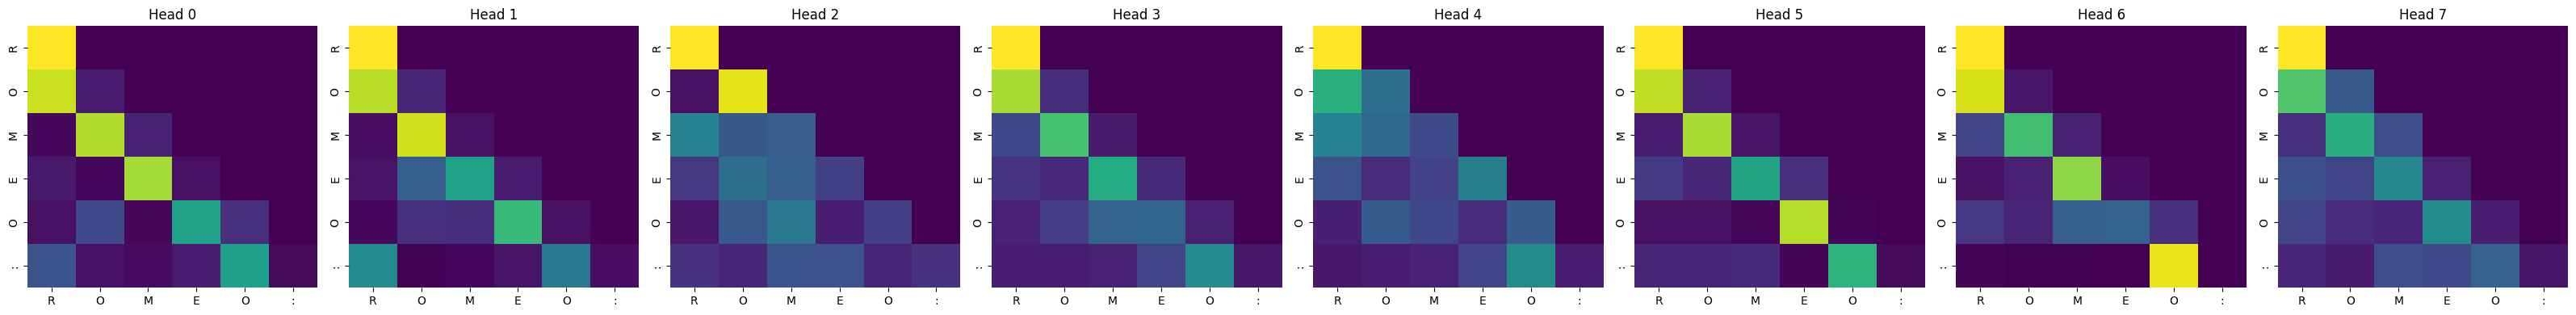

In [29]:
plot_multihead_attention("ROMEO:")

# PSKGPT v2 : Setup + Config

In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import random
from dataclasses import dataclass

# reproducibility
torch.manual_seed(42)

@dataclass
class Config:
    vocab_size = None
    block_size = 256

    # 🔥 SCALE UP
    n_embd = 384
    n_head = 8
    n_layer = 8

    dropout = 0.1
    bias = True

    batch_size = 32
    lr = 2e-4
    max_iters = 20000
    eval_interval = 200
    debug = True   # turn OFF later

    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()

print("Using Device:", cfg.device)

Using Device: cuda


# PSKGPT v2 : Load Dataset

In [2]:
import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

text = requests.get(url).text

print("Total characters:", len(text))
print("-" * 50)
print(text[:1000])   # preview first 1000 chars

Total characters: 1115394
--------------------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for

# PSKGPT v2 : BPE Tokenizer


In [3]:

import re
from collections import Counter

def pretokenize(text):
    return re.findall(r"\w+|[^\w\s]", text)

words = pretokenize(text)

vocab = Counter()

for word in words:
    tokens = tuple(list(word) + ['</w>'])
    vocab[tokens] += 1

def get_pair_counts(vocab):
    pairs = Counter()
    for word, freq in vocab.items():
        for i in range(len(word) - 1):
            pairs[(word[i], word[i+1])] += freq
    return pairs

def merge_pair(pair, vocab):
    new_vocab = Counter()
    replacement = pair[0] + pair[1]

    for word, freq in vocab.items():
        new_word = []
        i = 0

        while i < len(word):
            if i < len(word) - 1 and (word[i], word[i+1]) == pair:
                new_word.append(replacement)
                i += 2
            else:
                new_word.append(word[i])
                i += 1

        new_vocab[tuple(new_word)] += freq

    return new_vocab
    
num_merges = 1000   # start small (later increase)
merges = []

for i in range(num_merges):
    pairs = get_pair_counts(vocab)
    if not pairs:
        break

    best = max(pairs, key=pairs.get)
    merges.append(best)
    vocab = merge_pair(best, vocab)

print("Total merges learned:", len(merges))

tokens = set()

for word in vocab:
    for t in word:
        tokens.add(t)

tokens = sorted(tokens)

stoi = {t: i for i, t in enumerate(tokens)}
itos = {i: t for t, i in stoi.items()}

vocab_size = len(tokens)
cfg.vocab_size = vocab_size

print("Final vocab size:", vocab_size)

def encode(text):
    words = pretokenize(text)
    output = []

    for word in words:
        symbols = list(word) + ['</w>']

        for pair in merges:
            i = 0
            new_symbols = []

            while i < len(symbols):
                if i < len(symbols)-1 and (symbols[i], symbols[i+1]) == pair:
                    new_symbols.append(symbols[i] + symbols[i+1])
                    i += 2
                else:
                    new_symbols.append(symbols[i])
                    i += 1

            symbols = new_symbols

        output.extend(symbols)

    return [stoi[s] for s in output]

def decode(ids):
    tokens = [itos[i] for i in ids]
    text = ''.join(tokens)
    text = text.replace('</w>', ' ')
    return text

Total merges learned: 1000
Final vocab size: 1004


In [4]:
data = torch.tensor(encode(text), dtype=torch.long)

split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

In [5]:
print(encode("ROMEO speaking"))

[170, 845, 405, 601]


# PSKGPT v2 : Dataset + Batch Loader

In [6]:

# convert entire text to token ids
data = torch.tensor(encode(text), dtype=torch.long)

print("Total tokens:", len(data))
print("First 50 tokens:", data[:50])

# train / validation split
split = int(0.9 * len(data))
train_data = data[:split]
val_data   = data[split:]

print("Train tokens:", len(train_data))
print("Val tokens  :", len(val_data))


def get_batch(split_name="train"):
    source = train_data if split_name == "train" else val_data
    
    ix = torch.randint(len(source) - cfg.block_size - 1, (cfg.batch_size,))
    
    x = torch.stack([source[i : i + cfg.block_size] for i in ix])
    y = torch.stack([source[i + 1 : i + cfg.block_size + 1] for i in ix])
    
    x, y = x.to(cfg.device), y.to(cfg.device)
    return x, y


# quick test
xb, yb = get_batch("train")

print("Input shape :", xb.shape)
print("Target shape:", yb.shape)
print("One sample input :", xb[0][:20])
print("One sample target:", yb[0][:20])

Total tokens: 399734
First 50 tokens: tensor([ 69,  40,   8,  29, 479, 967, 772, 328, 414, 266, 459, 940, 888,   4,
        534, 652, 846,   6,  19,   8, 177, 744, 407,   4, 846,   6,  69,  40,
          8, 239, 273, 255, 793, 709, 949, 783, 888, 912, 384, 880, 912, 461,
        659, 823,  11,  19,   8, 165, 445, 709])
Train tokens: 359760
Val tokens  : 39974
Input shape : torch.Size([32, 256])
Target shape: torch.Size([32, 256])
One sample input : tensor([284, 284,  10,   3, 366, 676, 855, 717,   5, 602, 589, 804, 569, 403,
        990, 707, 885, 855, 429, 488], device='cuda:0')
One sample target: tensor([284,  10,   3, 366, 676, 855, 717,   5, 602, 589, 804, 569, 403, 990,
        707, 885, 855, 429, 488, 878], device='cuda:0')


# PSKGPT v2 : Single Head Self Attention


In [7]:
def apply_rope(x):
    B, T, C = x.shape

    if cfg.debug:
        print("\n--- RoPE DEBUG ---")
        print("Input:", x.shape)

    # split into pairs
    x = x.view(B, T, C // 2, 2)

    if cfg.debug:
        print("After split:", x.shape)

    # positions
    pos = torch.arange(T, device=x.device).float()

    # frequencies
    dim = torch.arange(C // 2, device=x.device).float()
    inv_freq = 1.0 / (10000 ** (dim / (C // 2)))

    angles = pos[:, None] * inv_freq[None, :]

    sin = torch.sin(angles)[None, :, :]   # (1, T, C//2)
    cos = torch.cos(angles)[None, :, :]   # (1, T, C//2)

    if cfg.debug:
        print("sin:", sin.shape)
        print("cos:", cos.shape)

    # split components
    x1 = x[..., 0]   # (B, T, C//2)
    x2 = x[..., 1]   # (B, T, C//2)

    if cfg.debug:
        print("x1:", x1.shape)
        print("x2:", x2.shape)

    # rotation
    x_rot_1 = x1 * cos - x2 * sin
    x_rot_2 = x1 * sin + x2 * cos

    if cfg.debug:
        print("x_rot_1:", x_rot_1.shape)
        print("x_rot_2:", x_rot_2.shape)

    # recombine
    x_rot = torch.stack([x_rot_1, x_rot_2], dim=-1)

    if cfg.debug:
        print("After rotation:", x_rot.shape)

    return x_rot.view(B, T, C)

In [8]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()

        self.key = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.query = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.value = nn.Linear(cfg.n_embd, head_size, bias=False)

        self.dropout = nn.Dropout(cfg.dropout)

        self.register_buffer(
            "tril",
            torch.tril(torch.ones(cfg.block_size, cfg.block_size))
        )

    def forward(self, x, past_k=None, past_v=None):
        B, T, C = x.shape

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        if past_k is not None:
            k = torch.cat([past_k, k], dim=1)
            v = torch.cat([past_v, v], dim=1)

        wei = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5)

        if past_k is None:
            wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))

        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        
        # 🔥 ADD THIS (for visualization)
        self.last_attn = wei.detach()
        
        out = wei @ v

        return out, k, v

In [9]:
print(cfg.n_embd // cfg.n_head)

48


# PSKGPT v2 : Multi Head Attention

In [10]:
class MultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()

        head_size = cfg.n_embd // cfg.n_head

        self.heads = nn.ModuleList(
            [Head(head_size) for _ in range(cfg.n_head)]
        )

        self.proj = nn.Linear(cfg.n_embd, cfg.n_embd)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x, past_kv=None):
        new_kv = []
        outputs = []
        
        for i, head in enumerate(self.heads):
            past_k, past_v = (None, None)
            if past_kv is not None:
                past_k, past_v = past_kv[i]
        
            out, k, v = head(x, past_k, past_v)
        
            outputs.append(out)
            new_kv.append((k, v))
        
        out = torch.cat(outputs, dim=-1)
        out = self.proj(out)
    
        return out, new_kv

# PSKGPT v2 :  Feed Forward Network


In [11]:
class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()

        hidden_dim = int((2/3) * 4 * cfg.n_embd)        
        self.w1 = nn.Linear(cfg.n_embd, hidden_dim, bias=cfg.bias)
        self.w2 = nn.Linear(cfg.n_embd, hidden_dim, bias=cfg.bias)

        self.proj = nn.Linear(hidden_dim, cfg.n_embd, bias=cfg.bias)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x):
        x1 = self.w1(x)                  # gate
        x2 = self.w2(x)                  # content

        return self.dropout(self.proj(F.silu(x1) * x2))

# PSKGPT v2 :  Transformer Block

In [12]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # x: (B, T, C)
        rms = x.pow(2).mean(dim=-1, keepdim=True).sqrt()
        x_norm = x / (rms + self.eps)
        return self.scale * x_norm

In [13]:
class Block(nn.Module):
    def __init__(self):
        super().__init__()

        self.norm1 = RMSNorm(cfg.n_embd)
        self.attn = MultiHeadAttention()

        self.norm2 = RMSNorm(cfg.n_embd)
        self.ffwd = FeedForward()

    def forward(self, x, past_kv=None):
        attn_out, new_kv = self.attn(self.norm1(x), past_kv)
        x = x + attn_out
        
        x = x + self.ffwd(self.norm2(x))
        
        return x, new_kv

# PSKGPT v2 :  Full GPT Model


In [14]:
class PSKGPT(nn.Module):
    def __init__(self):
        super().__init__()

        self.token_embedding = nn.Embedding(cfg.vocab_size, cfg.n_embd)
        self.position_embedding = nn.Embedding(cfg.block_size, cfg.n_embd)

        self.blocks = nn.ModuleList([Block() for _ in range(cfg.n_layer)])

        self.ln_f = RMSNorm(cfg.n_embd)

        self.lm_head = nn.Linear(cfg.n_embd, cfg.vocab_size, bias=False)
        self.lm_head.weight = self.token_embedding.weight

    def forward(self, idx, targets=None, past_kv=None):
        B, T = idx.shape

        tok_emb = self.token_embedding(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding(pos)

        x = tok_emb + pos_emb

        new_kv_all = []

        # 🔥 loop through blocks manually
        for i, block in enumerate(self.blocks):

            past = None
            if past_kv is not None:
                past = past_kv[i]

            x, new_kv = block(x, past)
            new_kv_all.append(new_kv)

        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            B, T, V = logits.shape
            logits_flat = logits.view(B * T, V)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss, new_kv_all

    @staticmethod
    def sample_top_p(probs, p=0.9):
        sorted_probs, sorted_indices = torch.sort(probs, descending=True)
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

        cutoff = cumulative_probs > p
        cutoff[..., 1:] = cutoff[..., :-1].clone()
        cutoff[..., 0] = False

        sorted_probs[cutoff] = 0.0
        sorted_probs = sorted_probs / sorted_probs.sum()

        idx = torch.multinomial(sorted_probs, 1)
        return sorted_indices[idx]

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
        past_kv = None

        for _ in range(max_new_tokens):

            idx_cond = idx[:, -1:] if past_kv else idx[:, -cfg.block_size:]

            logits, _, past_kv = self(
                idx_cond,
                past_kv=past_kv
            )

            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)

            if top_k is not None:
                v, _ = torch.topk(probs, top_k)
                probs[probs < v[:, [-1]]] = 0
                probs = probs / probs.sum(dim=-1, keepdim=True)

            if top_p is not None:
                idx_next = self.sample_top_p(probs[0], top_p).unsqueeze(0)
            else:
                idx_next = torch.multinomial(probs, 1)

            # 🔥 FIXED: this must be OUTSIDE else block
            idx = torch.cat((idx, idx_next), dim=1)

        return idx

# PSKGPT v2 :  Init Model

In [15]:
model = PSKGPT().to(cfg.device)

import os

if os.path.exists("best_v2.pt"):
    print("Loading best checkpoint...")
    model.load_state_dict(torch.load("best.pt"), strict=False)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.lr,
    weight_decay=0.1
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=int(0.8 * cfg.max_iters)
)

print("Model Parameters:",
      sum(p.numel() for p in model.parameters()) / 1e6,
      "Million")

Model Parameters: 14.668672 Million


# PSKGPT v2 :  Eval Loss

In [16]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()

    for split in ['train', 'val']:
        losses = torch.zeros(20)

        for k in range(20):
            xb, yb = get_batch(split)
            _, loss, _ = model(xb, yb)   # ✅ FIXED
            losses[k] = loss.item()

        out[split] = losses.mean()

    model.train()
    return out

# PSKGPT v2 :  Training Loop

In [17]:
# ==========================================
# 🔥 TRAINING SETUP
# ==========================================

best_val = float('inf')
patience = 20        # 🔥 increased
counter = 0

losses_log = []
val_losses_log = []
steps_log = []

# 🔥 Warmup settings
warmup_iters = 500
base_lr = cfg.lr

def get_lr(step):
    if step < warmup_iters:
        return base_lr * (step / warmup_iters)
    else:
        # cosine decay AFTER warmup
        progress = (step - warmup_iters) / (cfg.max_iters - warmup_iters)
        return base_lr * 0.5 * (1 + math.cos(math.pi * progress))


# ==========================================
# 🔥 TRAIN LOOP
# ==========================================

for step in range(cfg.max_iters):

    # ----------------------------
    # 🔥 SET LR (warmup + cosine)
    # ----------------------------
    lr = get_lr(step)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    # ----------------------------
    # 📦 Get batch
    # ----------------------------
    xb, yb = get_batch("train")

    # ----------------------------
    # 🔁 Forward
    # ----------------------------
    logits, loss, _ = model(xb, yb)
    losses_log.append(loss.item())

    # ----------------------------
    # 🔙 Backward
    # ----------------------------
    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    # ----------------------------
    # ⚙️ Update
    # ----------------------------
    optimizer.step()

    # ----------------------------
    # 📊 Evaluation
    # ----------------------------
    if step % cfg.eval_interval == 0:

        losses = estimate_loss()
        train_loss = losses['train']
        val_loss = losses['val']

        steps_log.append(step)
        val_losses_log.append(val_loss)

        print(f"\nstep {step}")
        print(f"train loss: {train_loss:.4f}")
        print(f"val loss  : {val_loss:.4f}")
        print(f"lr        : {lr:.6f}")

        # ----------------------------
        # 🔥 SMART EARLY STOPPING
        # ----------------------------
        if val_loss < best_val - 0.01:   # 🔥 tolerance added
            best_val = val_loss
            torch.save(model.state_dict(), "best_v2.pt")
            counter = 0
            print("✅ New best model saved")

        else:
            counter += 1
            print(f"⚠️ No improvement ({counter}/{patience})")

        # 🔥 only stop if really plateaued
        # if counter >= patience:
        #     print(f"\n🛑 Early stopping at step {step}")
        #     break


# ==========================================
# 💾 SAVE FINAL
# ==========================================

torch.save(model.state_dict(), "model_final.pt")

print("\n✅ Training complete")
print("Best validation loss:", best_val)


step 0
train loss: 261.9574
val loss  : 262.2986
lr        : 0.000000
✅ New best model saved

step 200
train loss: 11.3278
val loss  : 11.5788
lr        : 0.000080
✅ New best model saved

step 400
train loss: 6.3168
val loss  : 6.5901
lr        : 0.000160
✅ New best model saved

step 600
train loss: 4.8197
val loss  : 5.2374
lr        : 0.000200
✅ New best model saved

step 800
train loss: 4.4721
val loss  : 4.8767
lr        : 0.000200
✅ New best model saved

step 1000
train loss: 4.3413
val loss  : 4.7665
lr        : 0.000200
✅ New best model saved

step 1200
train loss: 4.2501
val loss  : 4.6765
lr        : 0.000199
✅ New best model saved

step 1400
train loss: 4.1746
val loss  : 4.6490
lr        : 0.000199
✅ New best model saved

step 1600
train loss: 4.0780
val loss  : 4.6086
lr        : 0.000198
✅ New best model saved

step 1800
train loss: 4.0313
val loss  : 4.5848
lr        : 0.000198
✅ New best model saved

step 2000
train loss: 3.8925
val loss  : 4.5614
lr        : 0.000197
✅

KeyboardInterrupt: 

In [18]:
print(model.lm_head.weight is model.token_embedding.weight)

True


In [20]:
model.load_state_dict(torch.load("best_v2.pt"))
model.eval()

PSKGPT(
  (token_embedding): Embedding(1004, 384)
  (position_embedding): Embedding(256, 384)
  (blocks): ModuleList(
    (0-7): 8 x Block(
      (norm1): RMSNorm()
      (attn): MultiHeadAttention(
        (heads): ModuleList(
          (0-7): 8 x Head(
            (key): Linear(in_features=384, out_features=48, bias=False)
            (query): Linear(in_features=384, out_features=48, bias=False)
            (value): Linear(in_features=384, out_features=48, bias=False)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): RMSNorm()
      (ffwd): FeedForward(
        (w1): Linear(in_features=384, out_features=1024, bias=True)
        (w2): Linear(in_features=384, out_features=1024, bias=True)
        (proj): Linear(in_features=1024, out_features=384, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )

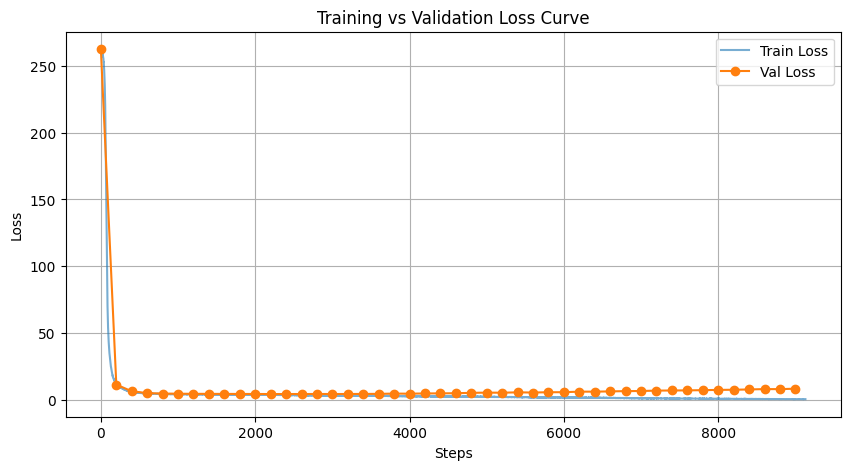

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# training loss (per step)
plt.plot(losses_log, label="Train Loss", alpha=0.6)

# validation loss (per eval_interval)
plt.plot(steps_log, val_losses_log, label="Val Loss", marker='o')

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.grid()

plt.show()

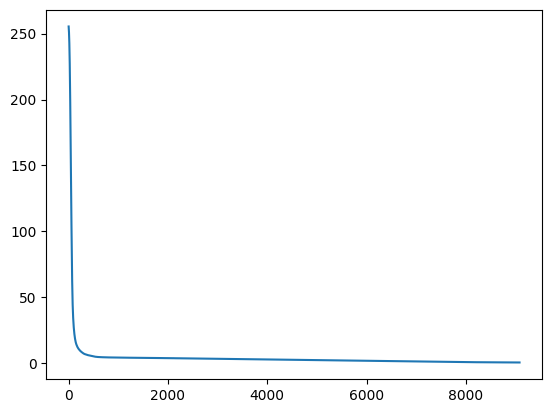

In [22]:
def moving_avg(x, k=50):
    return [sum(x[i:i+k])/k for i in range(len(x)-k)]

plt.plot(moving_avg(losses_log), label="Smoothed Train Loss")

# PSKGPT v2 : Inferencing

Loading best checkpoint...

================ TOKENIZER TESTS ================


===== DEBUG INFERENCE =====

Encoded IDs: [883]

Tokens: ['the</w>']

Decoded back: the 

===== DEBUG INFERENCE =====

Encoded IDs: [260]

Tokens: ['and</w>']

Decoded back: and 

===== DEBUG INFERENCE =====

Encoded IDs: [634]

Tokens: ['love</w>']

Decoded back: love 

===== DEBUG INFERENCE =====

Encoded IDs: [601]

Tokens: ['king</w>']

Decoded back: king 

===== DEBUG INFERENCE =====

Encoded IDs: [170]

Tokens: ['ROMEO</w>']

Decoded back: ROMEO 

===== DEBUG INFERENCE =====

Encoded IDs: [114]

Tokens: ['JULIET</w>']

Decoded back: JULIET 

===== DEBUG INFERENCE =====

Encoded IDs: [79, 422, 605, 704, 987]

Tokens: ['H', 'el', 'l', 'o</w>', 'world</w>']

Decoded back: Hello world 

===== DEBUG INFERENCE =====

Encoded IDs: [78, 665, 693]

Tokens: ['Good</w>', 'mor', 'ning</w>']

Decoded back: Good morning 

================ GENERATION TESTS ================

---- Shakespeare Style ----

ROMEO : O , m

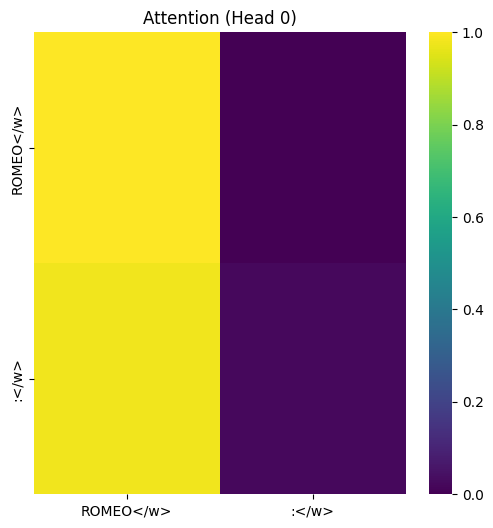

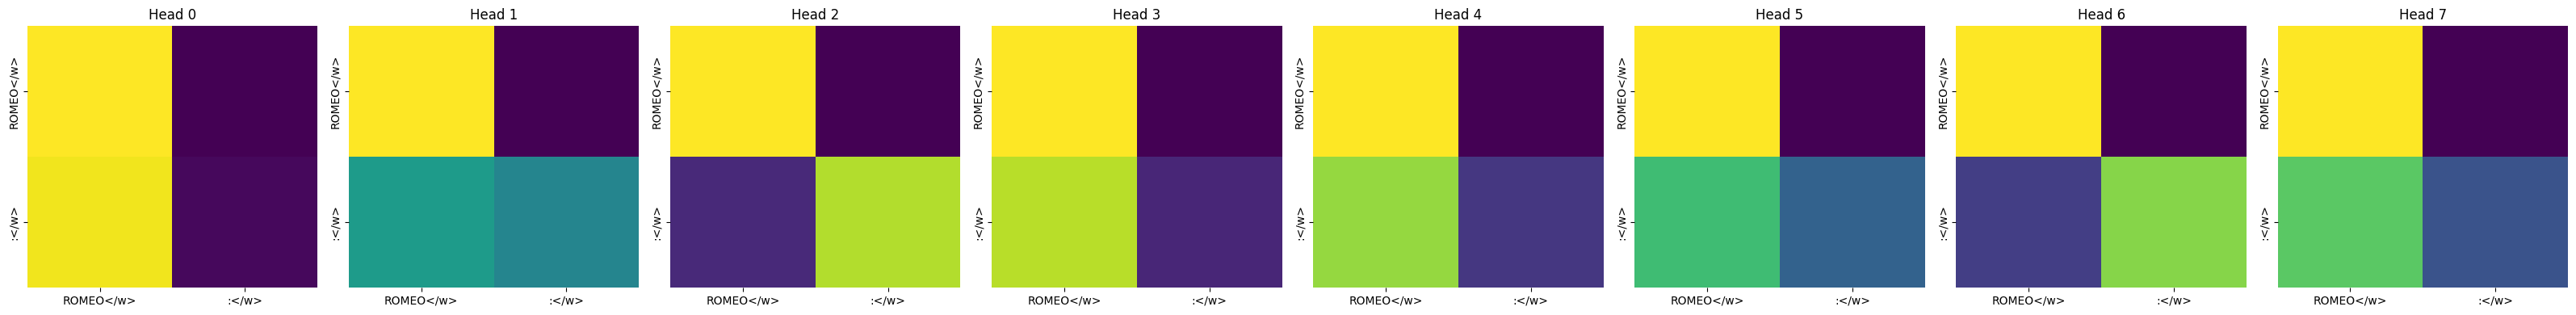

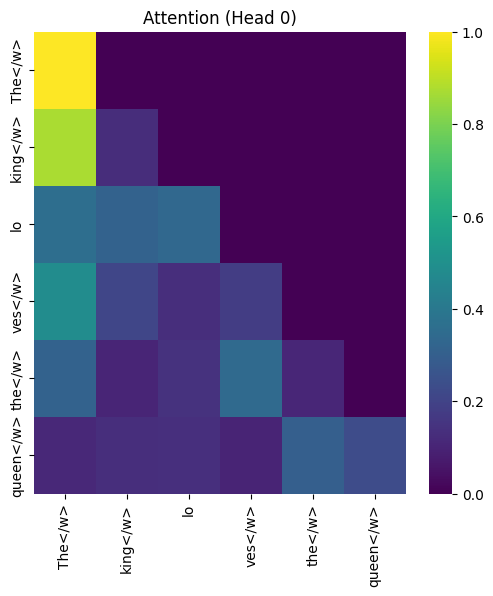

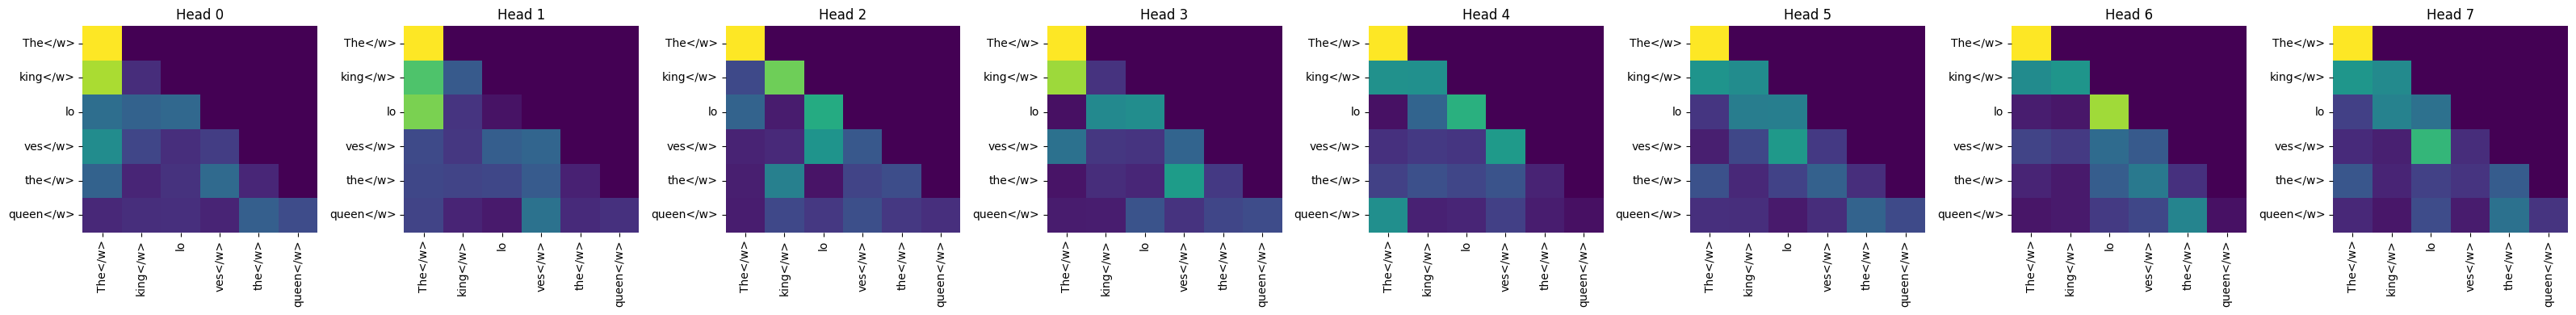

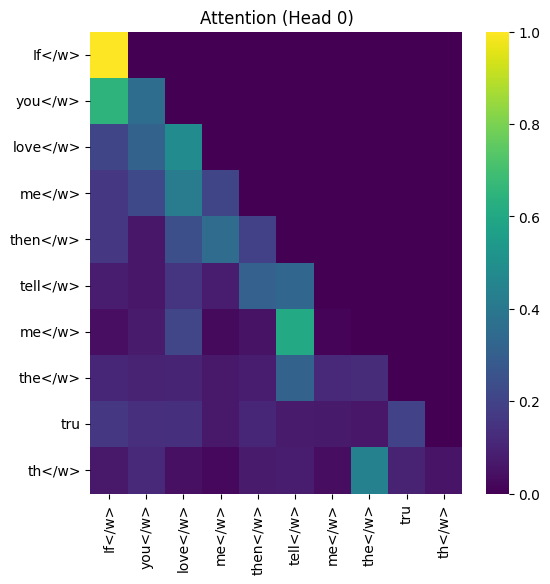

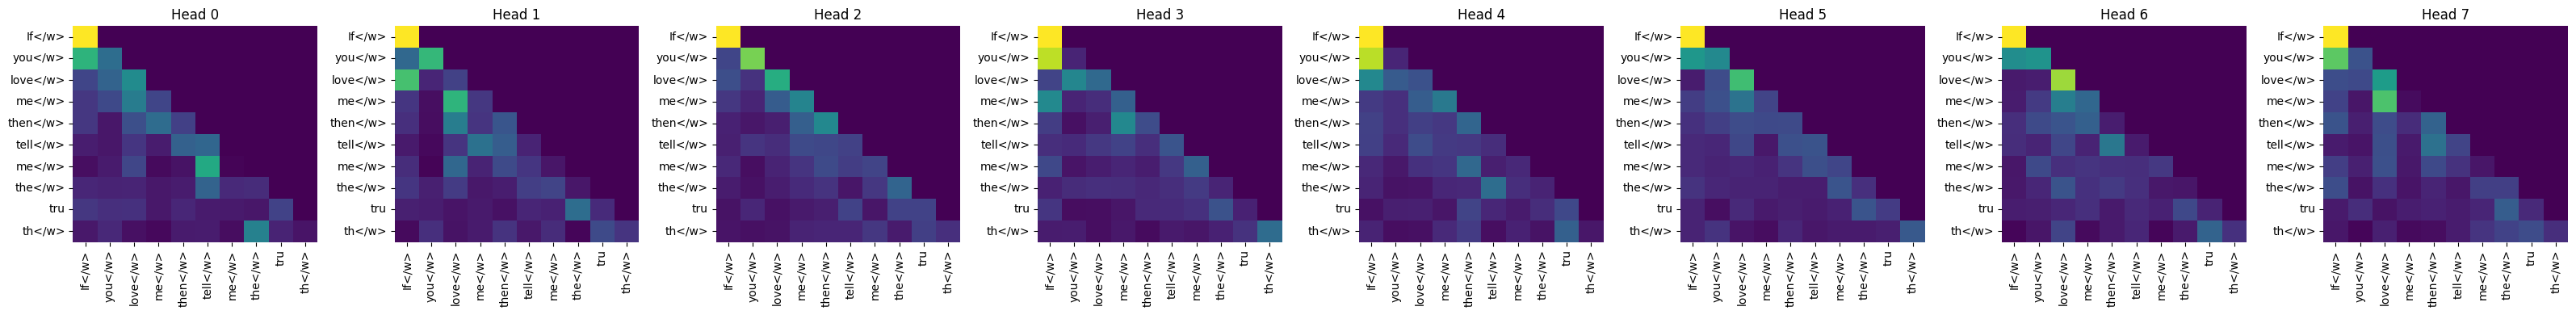


================ EDGE CASE TESTS ================

! I am weep a kill ' t , I loodly tt to see thee , And I think the way to your kinds , and I will ; I cannot be thou , I ' st not be my ked me . Geim , I do not I come , I am , I have I was a sman is not be not to ken , you have said . Saches to my soul , I am not for the goes , thou 
! First Citizen : Marcius , let ' Tis gods he be much I have no tius . CORIOLANUS : So ' tus ? SICINIUS : I ' ll go to bear the other , sir , sir , I ' s the people is dead ! Parmy tchurveldden the other day , I may not be your good to ken a , that the cer , I ' s the stury to my wear the twere it is no less a 
A : I say , I am , I fear the cle , to have my wounds , I ' ll give your good time you , I am I , I say ' ll say you shall be mark you that the cks of my poor Clarence , I do not what I am I will be a left her , And bear you , But what I come , that I am . Tye . Thanother sy him to - - - - - - I 
I pray you . FRIAR LAURIAR PETER : What news I am ,

In [25]:
# ==========================================
# 🔥 LOAD MODEL ONCE (IMPORTANT)
# ==========================================

import os

if os.path.exists("best_v2.pt"):
    print("Loading best checkpoint...")
    model.load_state_dict(torch.load("best_v2.pt"))

model.eval()


# ==========================================
# 🔥 GENERATION FUNCTION (FIXED)
# ==========================================

def generate_text(
    prompt="",
    max_new_tokens=200,
    temperature=0.8,
    top_k=None,
    top_p=None
):
    model.eval()

    # encode
    ids = encode(prompt)

    # handle empty prompt
    if len(ids) == 0:
        ids = [0]

    idx = torch.tensor([ids], dtype=torch.long).to(cfg.device)

    with torch.no_grad():
        idx = model.generate(
            idx,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p
        )

    return decode(idx[0].tolist())


# ==========================================
# 🔥 DEFAULT GENERATION WRAPPER
# ==========================================

GEN_CONFIG = {
    "temperature": 0.8,
    "top_k": 40,
    "top_p": 0.9
}

def gen(prompt, tokens=150):
    return generate_text(
        prompt,
        max_new_tokens=tokens,
        temperature=GEN_CONFIG["temperature"],
        top_k=GEN_CONFIG["top_k"],
        top_p=GEN_CONFIG["top_p"]
    )


# ==========================================
# 🔥 DEBUG TOKENIZER
# ==========================================

def debug_inference(prompt):
    print("\n===== DEBUG INFERENCE =====")

    ids = encode(prompt)
    print("\nEncoded IDs:", ids)

    tokens = [itos[i] for i in ids]
    print("\nTokens:", tokens)

    print("\nDecoded back:", decode(ids))


# ==========================================
# 🔥 NEXT TOKEN INSPECTION
# ==========================================

def inspect_next_token(prompt, top_k=10):
    model.eval()

    ids = encode(prompt)
    if len(ids) == 0:
        ids = [0]

    context = torch.tensor([ids], dtype=torch.long).to(cfg.device)

    with torch.no_grad():
        logits, _, _ = model(context)   # ✅ FIXED
        logits = logits[:, -1, :]
        probs = torch.softmax(logits, dim=-1)

    top_probs, top_idx = torch.topk(probs, top_k)

    print(f"\nPrompt: {repr(prompt)}\n")

    for i in range(top_k):
        idx = top_idx[0, i].item()
        raw_token = itos[idx]
        decoded = decode([idx])
        prob = top_probs[0, i].item()

        print(f"{repr(raw_token)} → {repr(decoded)} : {prob:.4f}")


# ==========================================
# 🔥 ATTENTION VISUALIZATION (SINGLE HEAD)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

def plot_attention(prompt):
    model.eval()

    ids = encode(prompt)
    if len(ids) == 0:
        ids = [0]

    context = torch.tensor([ids], dtype=torch.long).to(cfg.device)

    with torch.no_grad():
        model(context)

    head = model.blocks[0].attn.heads[0]
    attn = head.last_attn[0].cpu().numpy()

    tokens = [itos[i] for i in ids]
    T = len(tokens)

    plt.figure(figsize=(6, 6))
    sns.heatmap(
        attn[:T, :T],
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="viridis"
    )
    plt.title("Attention (Head 0)")
    plt.show()


# ==========================================
# 🔥 MULTI-HEAD ATTENTION VISUALIZATION
# ==========================================

def plot_multihead_attention(prompt, block_idx=0):
    model.eval()

    ids = encode(prompt)
    if len(ids) == 0:
        ids = [0]

    context = torch.tensor([ids], dtype=torch.long).to(cfg.device)

    with torch.no_grad():
        model(context)

    tokens = [itos[i] for i in ids]
    T = len(tokens)

    heads = model.blocks[block_idx].attn.heads
    num_heads = len(heads)

    fig, axes = plt.subplots(1, num_heads, figsize=(4 * num_heads, 4))

    for i, head in enumerate(heads):
        attn = head.last_attn[0].cpu().numpy()

        ax = axes[i] if num_heads > 1 else axes

        sns.heatmap(
            attn[:T, :T],
            xticklabels=tokens,
            yticklabels=tokens,
            cmap="viridis",
            cbar=False,
            ax=ax
        )

        ax.set_title(f"Head {i}")

    plt.tight_layout()
    plt.show()


# ==========================================
# 🔥 FULL EVALUATION SUITE
# ==========================================

print("\n================ TOKENIZER TESTS ================\n")

debug_inference("the ")
debug_inference("and ")
debug_inference("love ")
debug_inference("king ")
debug_inference("ROMEO ")
debug_inference("JULIET ")
debug_inference("Hello world ")
debug_inference("Good morning ")

# ------------------------------------------------

print("\n================ GENERATION TESTS ================\n")

print("---- Shakespeare Style ----\n")
print(gen("ROMEO:\n", 200))
print(gen("JULIET:\n", 200))
print(gen("KING:\n", 200))
print(gen("PRINCE:\n", 200))

print("\n---- Sentence Continuation ----\n")
print(gen("To be or not to be ", 150))
print(gen("The king said ", 150))
print(gen("I love you because ", 150))

print("\n---- Random Prompts ----\n")
print(gen("Hello world ", 150))
print(gen("Machine learning is ", 150))
print(gen("Today I feel ", 150))

# ------------------------------------------------

print("\n================ DECODING COMPARISON ================\n")

print("---- Top-K Only ----\n")
print(generate_text("ROMEO:\n", 150, temperature=0.8, top_k=40, top_p=None))

print("\n---- Top-K + Top-P ----\n")
print(gen("ROMEO:\n", 150))

# ------------------------------------------------

print("\n================ LONG CONTEXT TEST ================\n")

long_prompt = "The king said that the queen who lived in the castle near the river was loved by all because "
print(gen(long_prompt, 200))

# ------------------------------------------------

print("\n================ PROMPT SENSITIVITY ================\n")

print("Short Prompt:")
print(gen("King ", 100))

print("\nLong Prompt:")
print(gen("King Richard the third of England said that ", 100))

# ------------------------------------------------

print("\n================ NEXT TOKEN TESTS ================\n")

inspect_next_token("ROMEO:\n")
inspect_next_token("JULIET:\n")
inspect_next_token("The king ")
inspect_next_token("I love ")
inspect_next_token("To be or not ")

# ------------------------------------------------

print("\n================ ATTENTION TESTS ================\n")

plot_attention("ROMEO:\n")
plot_multihead_attention("ROMEO:\n")

plot_attention("The king loves the queen ")
plot_multihead_attention("The king loves the queen ")

plot_attention("If you love me then tell me the truth ")
plot_multihead_attention("If you love me then tell me the truth ")

# ------------------------------------------------

print("\n================ EDGE CASE TESTS ================\n")

print(gen("", 100))
print(gen(" ", 100))
print(gen("A ", 100))
print(gen("I ", 100))

debug_inference("xyzabc ")
print(gen("xyzabc ", 100))

# ------------------------------------------------

print("\n================ TOKEN LENGTH CHECK ================\n")

print("ROMEO:", len(encode("ROMEO:")))
print("the :", len(encode("the ")))
print("king:", len(encode("king ")))
print("Hello world:", len(encode("Hello world ")))

# ------------------------------------------------

print("\n================ ENCODE-DECODE CHECK ================\n")

text = "The king loves the queen "
ids = encode(text)
decoded = decode(ids)

print("Original:", text)
print("Decoded :", decoded)